## Problem Statement
- The goal of this project is to analyze a medical dataset to understand the key factors affecting Chronic Kidney Disease (CKD). 
Through data cleaning and visualization, we aim to identify patterns and differences between CKD and non-CKD patients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("kidney_disease.csv")
dff = pd.read_csv("kidney_disease.csv")

### Data Overview
- Understanding the structure, number of columns, and data types.

In [3]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [4]:
""""
age → Age of patient (0-100 years)
bp → Blood pressure (~50-180 mm Hg)
sg → Specific gravity (1.005 - 1.025)
al → Albumin (0-5, ordinal scale)
su → Sugar (0-5, ordinal scale)
rbc → Red blood cells (normal / abnormal)
pc → Pus cells (normal / abnormal)
pcc → Pus cell clumps (present / notpresent)
ba → Bacteria (present / notpresent)
bgr → Blood glucose random (~70-500 mg/dL)
bu → Blood urea (~10-200 mg/dL)
sc → Serum creatinine (~0.5-15 mg/dL)
sod → Sodium (~110-150 mEq/L)
pot → Potassium (~2.5-6 mEq/L)
hemo → Hemoglobin (~3-18 g/dL)
pcv → Packed cell volume (~20-55 %)
wc → White blood cells (~4,000-20,000 cells/µL)
rc → Red blood cells (~2-6 million cells/µL)
htn → Hypertension (yes / no)
dm → Diabetes mellitus (yes / no)
cad → Coronary artery disease (yes / no)
appet → Appetite (good / poor)
pe → Pedal edema (yes / no)
ane → Anemia (yes / no)
classification → Target (ckd / notckd)

"""

'"\nage → Age of patient (0-100 years)\nbp → Blood pressure (~50-180 mm Hg)\nsg → Specific gravity (1.005 - 1.025)\nal → Albumin (0-5, ordinal scale)\nsu → Sugar (0-5, ordinal scale)\nrbc → Red blood cells (normal / abnormal)\npc → Pus cells (normal / abnormal)\npcc → Pus cell clumps (present / notpresent)\nba → Bacteria (present / notpresent)\nbgr → Blood glucose random (~70-500 mg/dL)\nbu → Blood urea (~10-200 mg/dL)\nsc → Serum creatinine (~0.5-15 mg/dL)\nsod → Sodium (~110-150 mEq/L)\npot → Potassium (~2.5-6 mEq/L)\nhemo → Hemoglobin (~3-18 g/dL)\npcv → Packed cell volume (~20-55 %)\nwc → White blood cells (~4,000-20,000 cells/µL)\nrc → Red blood cells (~2-6 million cells/µL)\nhtn → Hypertension (yes / no)\ndm → Diabetes mellitus (yes / no)\ncad → Coronary artery disease (yes / no)\nappet → Appetite (good / poor)\npe → Pedal edema (yes / no)\nane → Anemia (yes / no)\nclassification → Target (ckd / notckd)\n\n'

In [5]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
df.shape

(400, 26)

In [7]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [9]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


#### Checking Null Values

In [10]:
df.drop('id',axis=1,inplace=True)
dff.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

### Data Manipulation

In [11]:
df.replace("?",np.nan,inplace=True)

In [12]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

num_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [13]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [15]:
df.dtypes

age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [16]:
dff.duplicated().sum()

np.int64(0)

In [17]:
df["classification"].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [18]:
df["classification"] = df["classification"].str.strip()
df["classification"].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

### Data Cleaning Summary
- Replaced '?' with missing values  
- Removed extra spaces from text columns  
- Converted numeric columns properly  
- Filled missing values:
  - Mean → numerical
  - Mode → categorical  
- Checked for duplicates and consistency  

Dataset is now clean and ready for analysis.

## Exploratory Data Analysis
- Various visualizations were performed to understand the dataset:

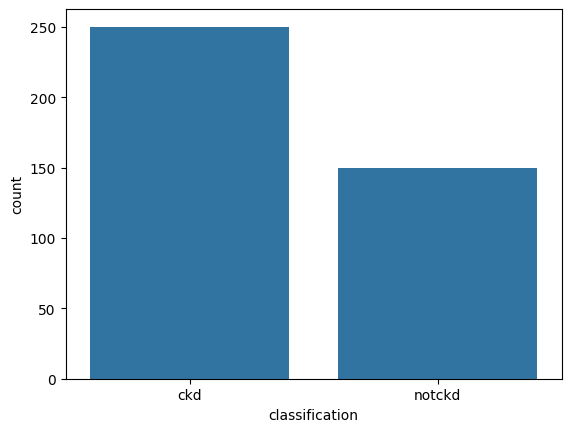

In [19]:
sns.countplot(x="classification",data=df)
plt.show()

- The dataset contains both CKD and non-CKD cases with a slight imbalance.

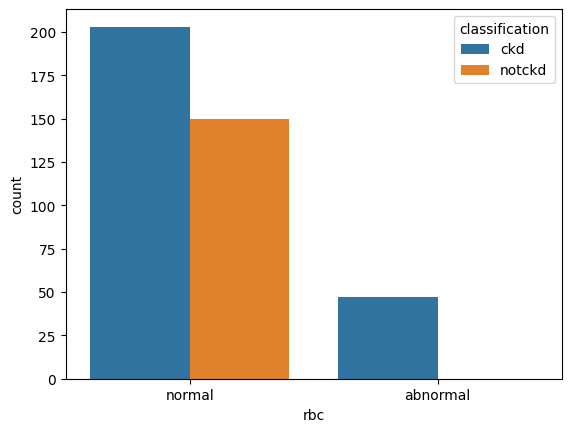

In [20]:
sns.countplot(x="rbc",hue="classification",data=df)
plt.show()

- Abnormal RBC values are more frequent in CKD patients.

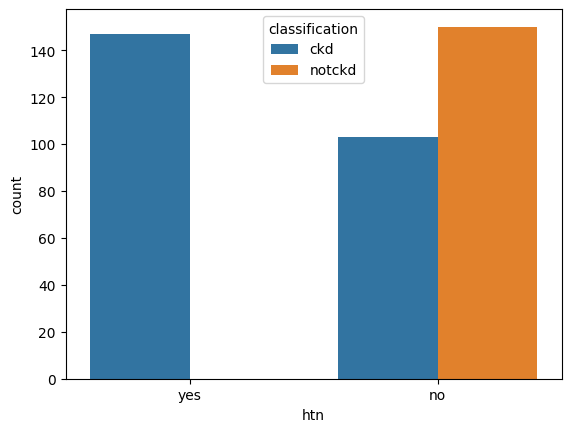

In [21]:
sns.countplot(x="htn",hue="classification",data=df)
plt.show()

- Patients with hypertension show a higher likelihood of CKD.

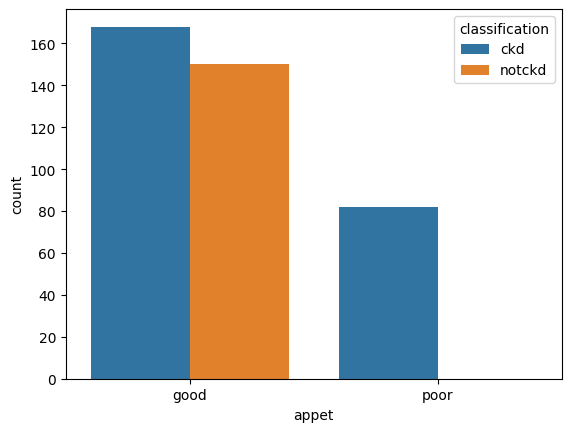

In [22]:
sns.countplot(x="appet",hue="classification",data=df)
plt.show()

- Poor appetite is more commonly observed in CKD patients.

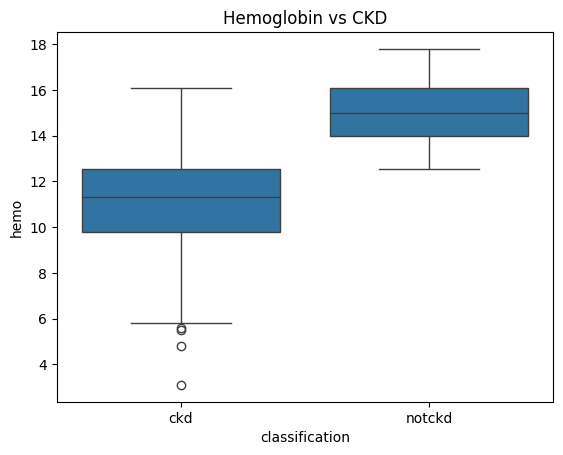

In [23]:
sns.boxplot(x='classification', y='hemo', data=df)
plt.title("Hemoglobin vs CKD")
plt.show()

- CKD patients tend to have lower hemoglobin levels.

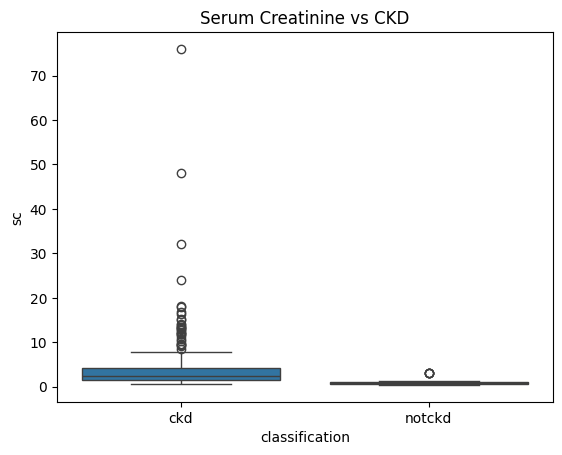

In [24]:
sns.boxplot(x='classification', y='sc', data=df)
plt.title("Serum Creatinine vs CKD")
plt.show()

- Higher serum creatinine levels are strongly associated with CKD.

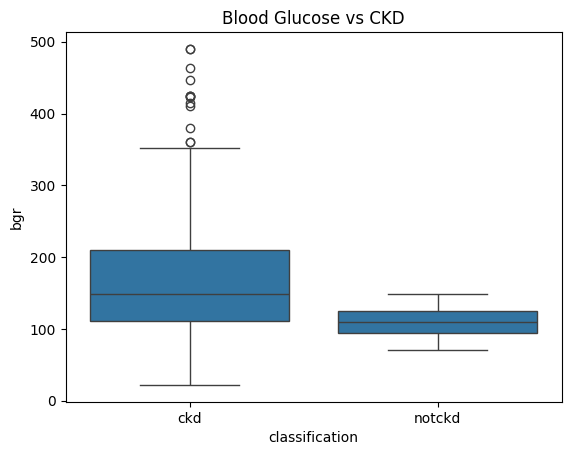

In [25]:
sns.boxplot(x='classification', y='bgr', data=df)
plt.title("Blood Glucose vs CKD")
plt.show()

- CKD patients generally show higher blood glucose levels.

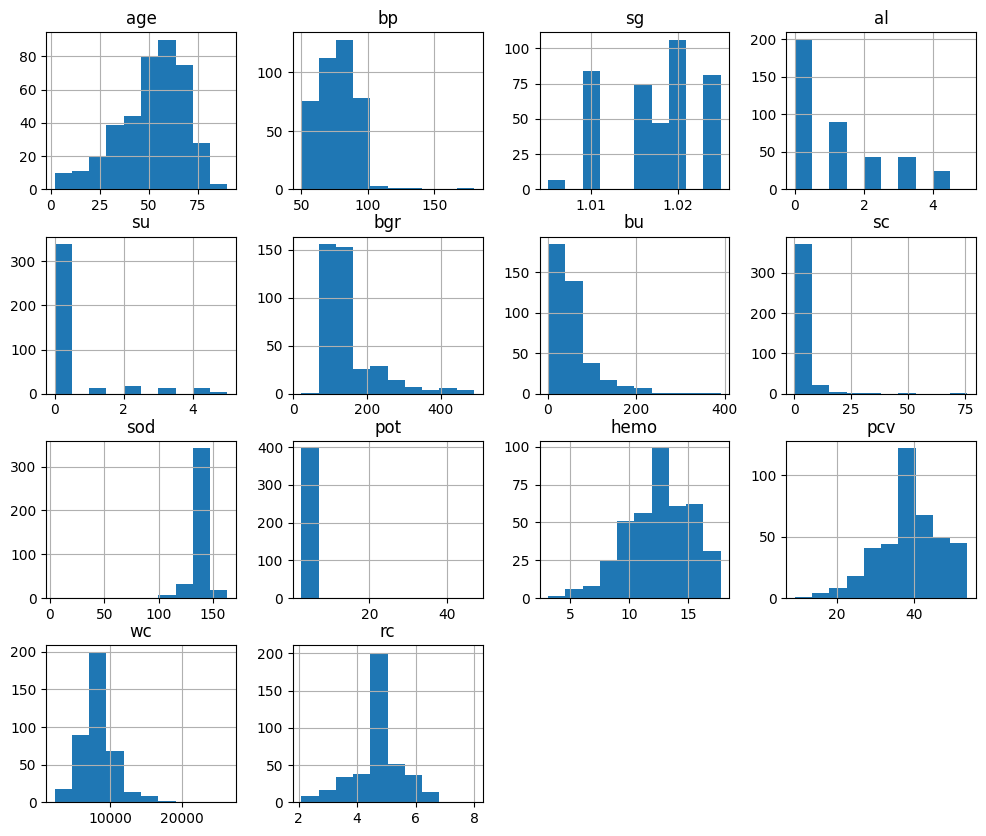

In [26]:
df.hist(figsize=(12,10))
plt.show()

- Some features are concentrated in specific ranges, indicating non-normal distribution.

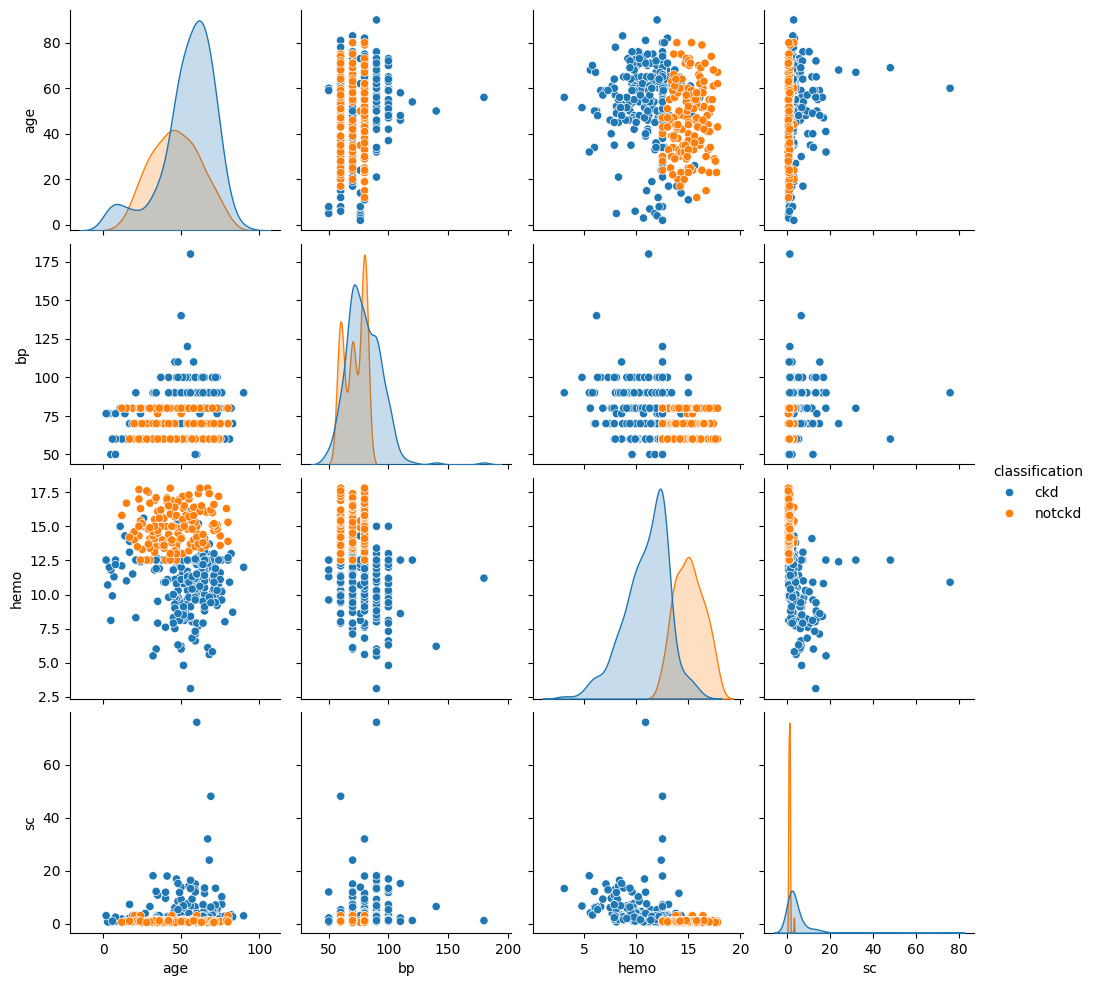

In [27]:
sns.pairplot(df[['age','bp','hemo','sc','classification']], hue='classification')
plt.show()

- Certain features show clear separation between CKD and non-CKD cases.

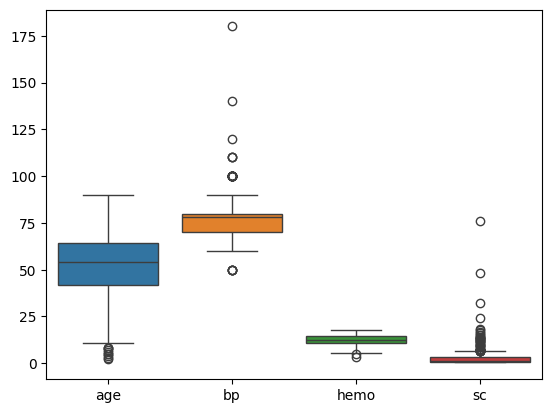

In [28]:
sns.boxplot(data=df[['age','bp','hemo','sc']])
plt.show()

- Outliers are present in key medical features, indicating variability in patient conditions.

## EDA SUMMARY

####  Data Visualization

- Analyzed CKD vs non-CKD distribution  
- Compared categorical features (RBC, HTN, Appetite)  
- Used boxplots for numerical features  
- Used histograms for distribution    

EDA helped in understanding patterns in the data.

In [29]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.000000,...,44.0,7800.0,5.200000,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,148.036517,...,38.0,6000.0,4.707435,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.000000,...,31.0,7500.0,4.707435,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.000000,...,32.0,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.000000,...,35.0,7300.0,4.600000,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.000000,...,47.0,6700.0,4.900000,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.000000,...,54.0,7800.0,6.200000,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.000000,...,49.0,6600.0,5.400000,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.000000,...,51.0,7200.0,5.900000,no,no,no,good,no,no,notckd


In [30]:
df.to_csv("cleaned_kidney_data.csv",index=False)

### Machine Learning : CKD Prediction

In [31]:
df_ml = df.copy()

#### Label Encoding
- Categorical columns were converted into numerical values using Label Encoding so that machine learning algorithms could process the data.

In [32]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns
cat_cols = [
    'rbc','pc','pcc','ba',
    'htn','dm','cad',
    'appet','pe','ane',
    'classification'
]

# Label Encoding
le = LabelEncoder()

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

In [33]:
df_ml.dtypes

age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification      int64
dtype: object

### Feature Selection

- X contains all input features
- y contains the target variable (CKD / Not CKD)

In [34]:
# Features and target
X = df_ml.drop('classification', axis=1)
y = df_ml['classification']

### Train Test Split

The dataset was divided into training and testing sets.

- 80% data used for training
- 20% data used for testing

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression Model
- Logistic Regression was trained to classify CKD and non-CKD patients.
- The model achieved strong prediction performance with high accuracy and recall.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9875
Precision: 0.9655172413793104
Recall: 1.0
F1 Score: 0.9824561403508771

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



c:\Users\KUNAL NIGEWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model.

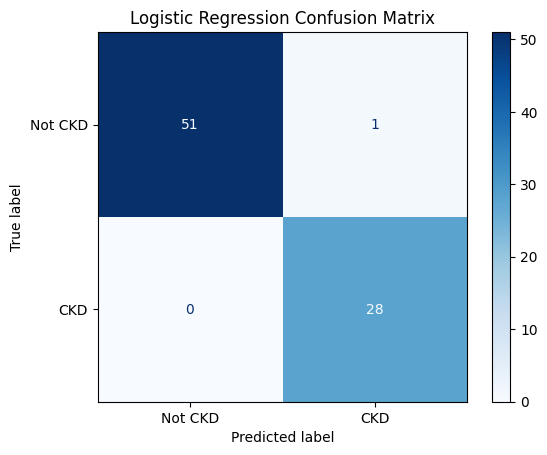

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not CKD', 'CKD']
)

disp.plot(cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Random Forest Model

Random Forest achieved strong overall performance and improved CKD prediction accuracy.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



- Since the data is small, we got {Accuarcy, Reacll, Precision, F1 Score} = 1

### Random Forest Confusion Matrix

The Random Forest confusion matrix shows that most CKD and non-CKD cases were classified correctly.

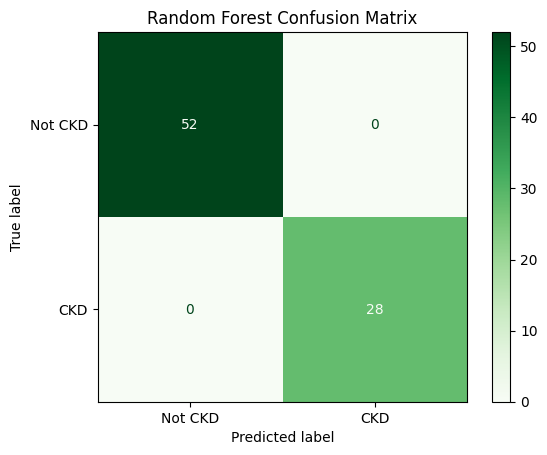

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not CKD', 'CKD']
)

disp.plot(cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.show()

### ROC-AUC Curve

ROC-AUC curve is used to measure the classification performance of machine learning models.

- Higher AUC score indicates better model performance.
- The curve closer to the top-left corner represents a stronger classifier.

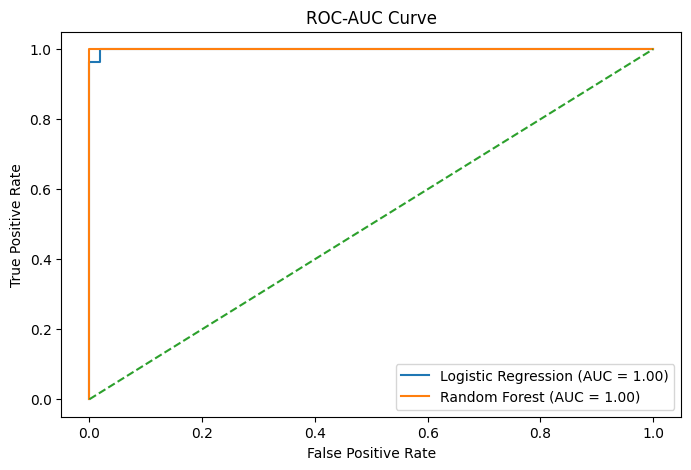

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probabilities
lr_probs = lr.predict_proba(X_test)[:,1]

# Random Forest probabilities
rf_probs = rf.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot ROC Curve
plt.figure(figsize=(8,5))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.2f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()

plt.show()

### ROC-AUC Insight

- Random Forest achieved a higher AUC score compared to Logistic Regression.
- The ROC curve indicates strong classification performance for CKD prediction.

### Feature Importance

Feature importance identifies the most influential medical attributes for CKD prediction.

Packed cell volume, hemoglobin, and serum creatinine were among the most important features.

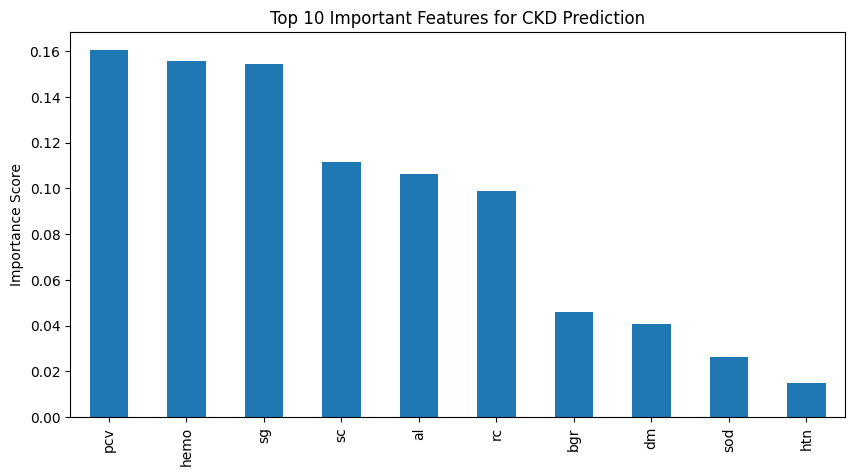

In [41]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features for CKD Prediction")
plt.ylabel("Importance Score")
plt.show()

# Final Conclusion

This project successfully analyzed Chronic Kidney Disease (CKD) data using Exploratory Data Analysis and Machine Learning techniques.

## Key Findings

- Medical attributes such as packed cell volume, hemoglobin, and serum creatinine showed strong relationships with CKD.
- Logistic Regression and Random Forest models were trained for CKD prediction.
- Random Forest achieved better overall performance with higher accuracy and ROC-AUC score.
- Confusion matrices and ROC curves showed strong classification capability for CKD detection.
- Feature importance analysis identified the most influential medical features for prediction.

This project demonstrates how machine learning can assist in early CKD detection and healthcare decision-making.